In [11]:
from numba import njit, int64, float64
from numba.experimental import jitclass
from numba.typed import List
from numba import types
import numpy as np


# PAIR_TYPE = types.Tuple((float64, int64))
TUPLE_TYPE = types.Tuple((float64, int64))

heap_spec = [
    ('data', types.ListType(TUPLE_TYPE))
]

@jitclass(heap_spec)
class Heap:

    def __init__(self):
        self.data = List.empty_list(TUPLE_TYPE)

    def push(self, key, idx):
        self.data.append((key, idx))
        i = len(self.data) - 1
        while i > 0:
            parent = (i - 1) // 2
            if self.data[i][0] <= self.data[parent][0]:
                break
            self.data[i], self.data[parent] = self.data[parent], self.data[i]
            i = parent

    def pop(self):
        top = self.data[0]
        last = self.data.pop()
        if len(self.data) == 0:
            return top
        self.data[0] = last
        i = 0
        while True:
            left = 2 * i + 1
            right = 2 * i + 2
            largest = i
            if left < len(self.data) and self.data[left][0] > self.data[largest][0]:
                largest = left
            if right < len(self.data) and self.data[right][0] > self.data[largest][0]:
                largest = right
            if largest == i:
                break
            self.data[i], self.data[largest] = self.data[largest], self.data[i]
            i = largest
        return top
    
heap = Heap()
heap.push(-1.0, 0)
heap.pop()

(-1.0, 0)

In [52]:
import numpy as np

from numba.experimental import jitclass
from numba.types import int64, float64, FunctionType
from numba.typed import List
from numba import njit

from opticon import Propositionalization, compute_bounds, equal_width_propositionalization
from testdata import mvn_with_correlation

@jitclass
class CanonicalTreeSearchNode:

    key: int64[:]
    critical: int64[:]
    remaining: int64[:]
    support: int64[:]

    def __init__(self, key, critical, remaining, support):
        self.key = key
        self.critical = critical
        self.remaining =remaining
        self.support = support

def node_to_string(node):
    return f'Node({node.key}, {node.value}, {node.bound})'

@njit
def dummy_obj(node):
    return float64(len(node.key))

@njit
def dummy_bnd(node):
    return float64(len(node.key) + len(node.remaining))

CanonicalTreeSearchNodeType = CanonicalTreeSearchNode.class_type.instance_type

@jitclass
class CanonicalTreeSearch:

    x: float64[:, :]
    prop: Propositionalization

    def __init__(self, x, prop):
        self.x = x
        self.prop = prop

    def refinement(self, node):
        res = List()
        for p_idx in range(len(node.remaining)):
            p = node.remaining[p_idx]
            # _key = np.append(node.key, p)
            _key = np.empty(len(node.key) + 1, dtype=np.int64)
            _key[:-1] = node.key
            _key[-1] = p
            _sup = self.prop.support(p, self.x[node.support])
            #_crit = np.append(node.critical, node.remaining[:p_idx])
            _crit = np.empty(len(node.critical) + p_idx, dtype=np.int64)
            _crit[:len(node.critical)] = node.critical
            _crit[len(node.critical):] = node.remaining[:p_idx]
            l, u = compute_bounds(self.x[_sup])
            if len(self.prop.trivial(l, u, _crit))>0: #canonicity check
                continue
            _remaining = self.prop.nontrivial(l, u, node.remaining[p_idx+1:])
            res.append(CanonicalTreeSearchNode(_key, _crit, _remaining, _sup))
        return res

    def make_root(self):
        l, u = compute_bounds(self.x)
        remaining = self.prop.nontrivial(l, u, np.arange(len(self.prop)))
        empty = np.empty(0, dtype=np.int64)
        return CanonicalTreeSearchNode(empty, empty, remaining, np.arange(len(self.x)))
    
    def run(self, max_depth = 8):
        heap = Heap()
        nodes = List.empty_list(CanonicalTreeSearchNodeType) #List.empty_list(CanonicalTreeSearchNode.class_type.instance_type)
        freelist = List.empty_list(int64)

        root = self.make_root()
        nodes.append(root)
        heap.push(-dummy_bnd(root), 0)

        best_value = dummy_obj(root)
        created = 1
        non_canonical = 0

        while len(heap.data) > 0:
            neg_bound, idx = heap.pop()
            node = nodes[idx]
            freelist.append(idx)

            if -neg_bound < best_value:
                continue
            if len(node.key) >= max_depth:
                continue

            children = self.refinement(node)
            created += len(children)
            non_canonical += len(node.remaining) - len(children)

            for child in children:
                val = dummy_obj(child)
                bnd = dummy_bnd(child)
                if val > best_value:
                    best_value = val

                if len(freelist) > 0:
                    reuse_idx = freelist.pop()
                    nodes[reuse_idx] = child
                    heap.push(-bnd, reuse_idx)
                else:
                    nodes.append(child)
                    heap.push(-bnd, len(nodes) - 1)

        print("Best value:", best_value)
        print("Total nodes created:", created)
        print("None canonical edges:", non_canonical)
        return best_value
        

x = mvn_with_correlation(100, seed=0)
prop = equal_width_propositionalization(x)
search = CanonicalTreeSearch(x, prop)
search.run(4)

Best value: 4.0
Total nodes created: 7037
None canonical edges: 18114


4.0

In [53]:
import heapq

@njit
def refinement(prop, x, node):
    res = List.empty_list(CanonicalTreeSearchNodeType)

    for p_idx in range(len(node.remaining)):
        p = node.remaining[p_idx]
        # key = np.append(node.key, p)
        key = np.empty(len(node.key) + 1, dtype=np.int64)
        key[:-1] = node.key
        key[-1] = p
        sup = prop.support(p, x[node.support])
        # crit = np.append(node.critical, node.remaining[:p_idx])
        crit = np.empty(len(node.critical) + p_idx, dtype=np.int64)
        crit[:len(node.critical)] = node.critical
        crit[len(node.critical):] = node.remaining[:p_idx]

        l, u = compute_bounds(x[sup])
        if len(prop.trivial(l, u, crit)) > 0:
            continue
        remaining = prop.nontrivial(l, u, node.remaining[p_idx+1:])
        res.append(CanonicalTreeSearchNode(key, crit, remaining, sup))

    return res

class PythonCanonicalTreeSearch:

    def __init__(self, x, prop):
        self.x = x
        self.prop = prop

    def make_root(self):
        l, u = compute_bounds(self.x)
        remaining = self.prop.nontrivial(l, u, np.arange(len(self.prop)))
        empty = np.empty(0, dtype=np.int64)
        return CanonicalTreeSearchNode(empty, empty, remaining, np.arange(len(self.x)))

    def run(self, max_depth):
        heap = []
        nodes = []

        root = self.make_root()
        nodes.append(root)
        heapq.heappush(heap, (-dummy_bnd(root), 0))

        best_value = dummy_obj(root)
        created = 1
        non_canonical = 0

        while heap:
            neg_bound, idx = heapq.heappop(heap)
            node = nodes[idx]

            if -neg_bound < best_value:
                continue
            if len(node.key) >= max_depth:
                continue

            children = refinement(self.prop, self.x, node)  # <- must be standalone @njit
            created += len(children)
            non_canonical += len(node.remaining) - len(children)

            for child in children:
                val = dummy_obj(child)
                bnd = dummy_bnd(child)
                if val > best_value:
                    best_value = val
                nodes.append(child)
                heapq.heappush(heap, (-bnd, len(nodes) - 1))

        print("Best value:", best_value)
        print("Total nodes created:", created)
        print("None canonical edges:", non_canonical)
        return best_value
    
python_search = PythonCanonicalTreeSearch(x, prop)
python_search.run(4)

Best value: 4.0
Total nodes created: 7037
None canonical edges: 18114


4.0

In [54]:
depths = list(range(2, 9))
python_times = []

for d in depths:
    python_search = PythonCanonicalTreeSearch(x, equal_width_propositionalization(x))
    python_result = %timeit -o python_search.run(d)
    python_times.append(python_result.best)

python_times

Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges:

[0.0015145575000060489,
 0.013028173330094433,
 0.08171278329973575,
 0.3892885829991428,
 1.4875784169998951,
 4.125001708001946,
 9.185869791996083]

In [39]:
python_times

[0.0016524512079922715,
 0.014204079170012847,
 0.09154249160055769,
 0.43059879199427087,
 1.6328543749987148,
 4.4483243329887046,
 9.978465500011225]

In [56]:
numba_times = []
for d in depths:
    numba_search = CanonicalTreeSearch(x, prop)
    numba_result = %timeit -o numba_search.run(d)
    numba_times.append(numba_result.best)

numba_times

Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges: 270
Best value: 2.0
Total nodes created: 159
None canonical edges:

[0.0012554129999916767,
 0.011264177919947542,
 0.06988515420089243,
 0.3279452919960022,
 1.1664450829994166,
 3.288414707989432,
 7.3139592920051655]

In [55]:
numba_times

[0.0014350308329885593,
 0.012873697920003906,
 0.08191609169880394,
 0.38709499999822583,
 1.3905546669993782,
 3.8525387499976205,
 8.592954082996584]

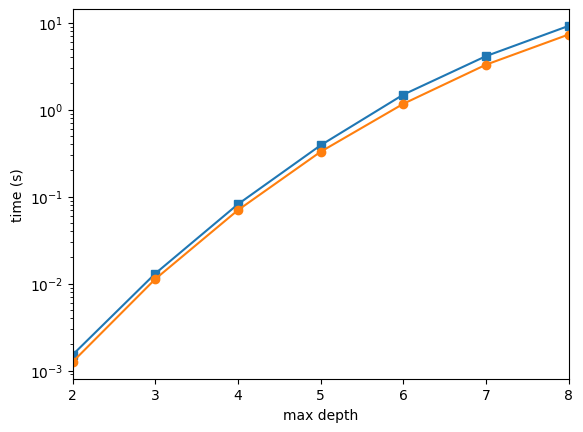

In [63]:
from matplotlib import pyplot as plt

plt.plot(depths, python_times, marker='s')
plt.plot(depths, numba_times, marker='o')
plt.xlabel('max depth')
plt.ylabel('time (s)')
plt.yscale('log')
plt.margins(x=0)
plt.show()

In [42]:
a = np.arange(10, dtype=np.int64)
b = 42

@njit
def using_append(a, b):
    return np.append(a, b)

@njit
def manual_append(a, b):
    out = np.empty(len(a) + 1, dtype=np.int64)
    out[:-1] = a
    out[-1] = b
    return out

using_append(a, b), manual_append(a, b)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 42]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 42]))

In [43]:
%timeit using_append(a, b)

471 ns ± 14.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [44]:
%timeit manual_append(a, b)

360 ns ± 7.21 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [48]:
a = np.arange(10, dtype=np.int64)
b = np.arange(15, dtype=np.int64)

@njit
def append_two_arrays(a, b):
    return np.append(a, b)

@njit
def manual_concat(a, b):
    out = np.empty(len(a) + len(b), dtype=np.int64)
    out[:len(a)] = a
    out[len(a):] = b
    return out

append_two_arrays(a, b), manual_concat(a, b)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  0,  1,  2,  3,  4,  5,  6,
         7,  8,  9, 10, 11, 12, 13, 14]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  0,  1,  2,  3,  4,  5,  6,
         7,  8,  9, 10, 11, 12, 13, 14]))

In [49]:
%timeit append_two_arrays(a, b)


459 ns ± 21 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [50]:
%timeit manual_concat(a, b)

420 ns ± 13.6 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
